# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Es la continuación de la Tarea 1, por lo que se utilizarán los mismos datos y se puede reutilizar cualquier parte del código de dicha tarea.

Puede copiar este notebook en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y las librerías Pandas y scikit-learn. Para esta tarea se recomienda consultar la sección [Extracting features from text files](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html) de la documentación oficial de scikit-learn.

Recuerde que **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook.

In [ ]:
from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...

## Descarga del dataset
Se utilizan los mismos datos que en la Tarea 1. Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas.

In [ ]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train", cache_dir="../data")
df = ds.to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


all-the-news-2-1-Component-ones-cluster-(…):   0%|          | 0.00/60.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30213 [00:00<?, ? examples/s]

# Parte 1: Dataset y representación numérica de texto

## 1. Preparación del dataset
Se utilizará un conjunto de datos reducido de los **tres medios de prensa con mayor cantidad de artículos**.
Se espera que utilice su propia versión de la función `clean_text()` de la Tarea 1.

Particione los datos para generar un conjunto de test del 30% del total, utilizando muestreo estratificado.

**Sugerencia**: utilice el parámetro `stratify` de la función `train_test_split` de scikit-learn y fije también el valor de `random_state` para obtener resultados reproducibles.

In [ ]:
top_3_publications = df["publication"].value_counts().head(3).index
df_top_3 = df[df["publication"].isin(top_3_publications)]


In [ ]:
pubs  = df_top_3['publication'].unique()
pub_id = {p: f"pubid{p.replace(' ', '').lower()}" for p in pubs}

In [ ]:
def preproces(S):
    pubs  = df_top_3['publication'].unique()

    if isinstance(S, str):
        for p in pubs:
            S = S.replace(p, pub_id[p])
    return S

In [ ]:
def not_a_letter(s):
    if not isinstance(s, str):
        return []
    return  [c for c in s if not c.isalpha()]
def get_not_letter(df, column):
    chars_df = df[column].apply(not_a_letter)
    all_chars = [char for sublist in chars_df for char in sublist]
    return list(set(all_chars))
#noalpha_chars = get_not_letter(df_filtered_top5, 'article')
def countt_words(df, column_name):
    return df[column_name].apply(lambda x: str(x).split()).explode().value_counts()

In [ ]:
def clean_text(df, column_name):
    noalpha_chars = get_not_letter(df, column_name)


    df2=df[column_name].apply(preproces)
    # Eliminar primeras palabras hasta el primer "\n"  xq???
    result = df2#.str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()
    print(f"Caracteres no alfabéticos encontrados: {len(noalpha_chars)}")

   # for punc in ["[", "\n", ",", ":", "?"]:
    for punc in noalpha_chars: #  esta aparte del codigfo ya estaba implementada lo emjor seria solo quedarme con lo  alpha   y  no  ahcer la lsita de  nlo  que  es no aalpha para nno  tenner  que hacer  un doble  fiulytrado
       result = result.str.replace(punc, " ")

    return result

In [ ]:
df_top_3["CleanText"] = clean_text(df_top_3, "article")

Caracteres no alfabéticos encontrados: 124


/tmp/ipykernel_4007/53509051.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_3["CleanText"] = clean_text(df_top_3, "article")


In [ ]:
X = df_top_3["CleanText"]
y = df_top_3["publication"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43, stratify=y)

## 2. Verificación del balance de clases
Genere una visualización que permita verificar que el balance de artículos de cada medio es similar en train y test.

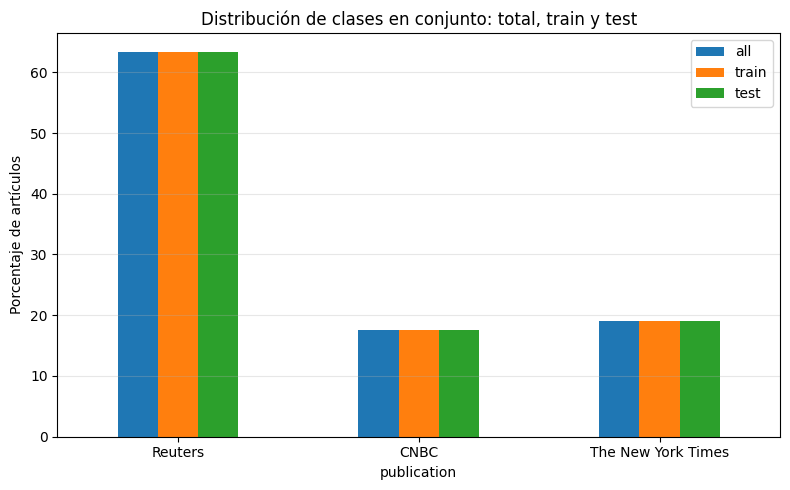

In [ ]:
classes = y.unique()

distribution = pd.DataFrame({
    "all": y.value_counts(normalize=True).reindex(classes) * 100,
    "train": y_train.value_counts(normalize=True).reindex(classes) * 100,
    "test": y_test.value_counts(normalize=True).reindex(classes) * 100
})

ax = distribution.plot(kind="bar", figsize=(8, 5))

ax.set_title("Distribución de clases en conjunto: total, train y test")
ax.set_xlabel("publication")
ax.set_ylabel("Porcentaje de artículos")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Representación Bag of Words
Transforme el texto del conjunto de entrenamiento a una representación numérica (features) de conteo de palabras (*bag of words*).
Explique brevemente cómo funciona esta técnica y muestre un ejemplo.
En particular, explique el tamaño de la matriz resultante y la razón por la que es una matriz *sparse*.

**Sugerencia**: puede ser útil imaginar qué sucedería con la memoria RAM requerida si no estuviéramos trabajando con un conjunto de datos reducido.

In [ ]:
import random
vectorizer = CountVectorizer()

X_train_bow = vectorizer.fit_transform(X_train[~X_train.isna()])

# tamaño de la matriz resultante
print(X_train_bow.shape)

# ejemplo: las primeras palabras del vocabulario y sus conteos en un documento
print(vectorizer.get_feature_names_out()[:10])

rand = random.randint(0,len(X_train_bow.toarray()))
print(X_train_bow.toarray()[rand][:20])
print(f"documento:{rand}")

(10252, 85435)
['aa' 'aaa' 'aaaawwwww' 'aaalto' 'aaaron' 'aab' 'aabar' 'aac' 'aachen'
 'aadmi']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
documento:5182


## 4. Representación TF-IDF
Explique brevemente qué es un **n-grama**.
Obtenga la representación numérica *Term Frequency - Inverse Document Frequency* (TF-IDF).
Explique brevemente en qué consiste esta transformación adicional.

In [ ]:
# TODO: Obtenga la representación TF-IDF del conjunto de entrenamiento

tf_idf_vectorizer = TfidfVectorizer()

X_train_tfidf = tf_idf_vectorizer.fit_transform(X_train[X_train.notna()])
# Muestre el tamaño de la matriz resultante
X_train_tfidf.shape


(10252, 85435)

## 5. Visualización PCA sobre TF-IDF
Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de TF-IDF.
Analice los resultados y compare qué sucede si utiliza:
- a) el filtrado de `stop_words` para idioma inglés;
- b) el parámetro `use_idf=True`;
- c) `ngram_range=(1,2)`.

Opcionalmente, también puede analizar qué sucede si no elimina los signos de puntuación.

¿Se pueden separar los medios de prensa utilizando sólo 2 componentes principales?
Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (por ejemplo, hasta 10 componentes).

Discuta además si la separación observada puede deberse a diferencias de estilo editorial, a diferencias temáticas o a pistas explícitas del medio que no hayan sido removidas en la limpieza.

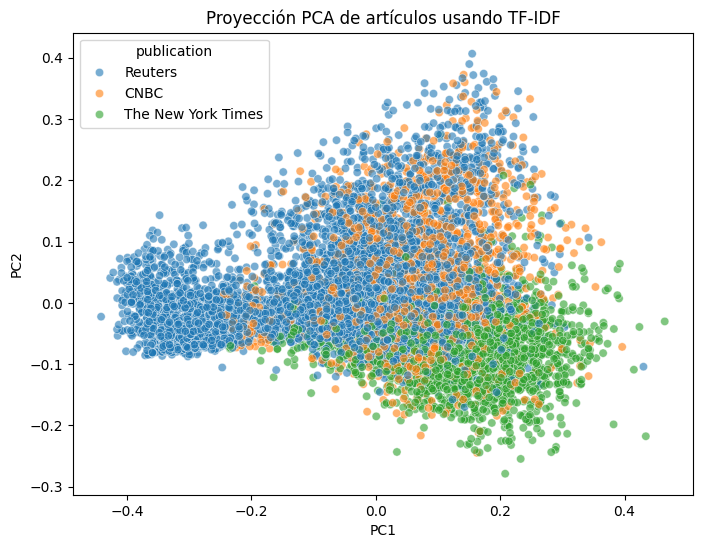

In [ ]:
# TODO: Aplique PCA con 2 componentes sobre X_train_tfidf y grafique los resultados,
# coloreando los puntos según el medio de prensa.

X_pca = PCA(n_components=2).fit_transform(X_train_tfidf)
y_pca = y_train[X_train.notna()]

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "publication": y_pca
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="publication",
    alpha=0.6
)

plt.title("Proyección PCA de artículos usando TF-IDF")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="publication")
plt.show()

In [ ]:
tf_idf_vectorizer_2 = TfidfVectorizer(stop_words="english", use_idf=True, ngram_range=(1,2))

X_train_tfidf_2 = tf_idf_vectorizer_2.fit_transform(X_train[X_train.notna()])

X_train_tfidf_2.shape

(10252, 1653251)

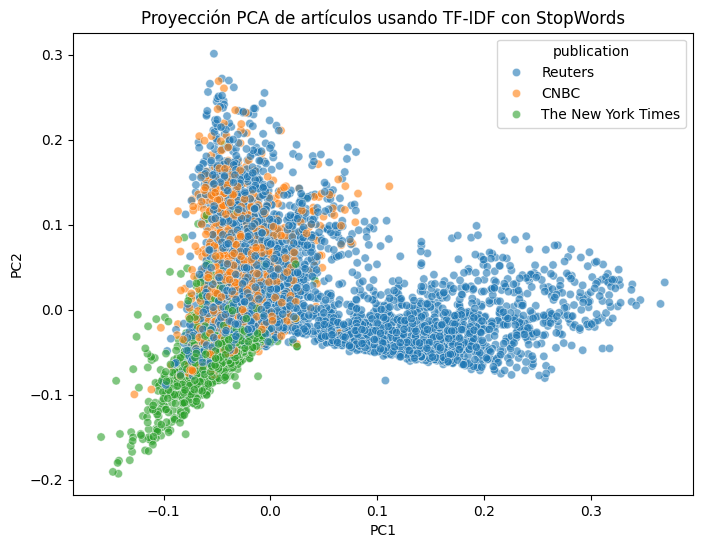

In [ ]:
X_pca_2 = PCA(n_components=2).fit_transform(X_train_tfidf_2)
y_pca_2 = y_train[X_train.notna()]

pca_df = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "publication": y_pca_2
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="publication",
    alpha=0.6
)

plt.title("Proyección PCA de artículos usando TF-IDF con StopWords")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="publication")
plt.show()

In [ ]:
X_pca_2 = PCA(n_components=2).fit_transform(X_train_tfidf_2)
y_pca_2 = y_train[X_train.notna()]

pca_df2 = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "publication": y_pca_2
})
pca_df2["dist"] = np.sqrt(
    pca_df2["PC1"]**2 + pca_df2["PC2"]**2
)

In [ ]:
print(X_train_tfidf_2.shape[0])
print(pca_df2.shape[0])
feature_names = tf_idf_vectorizer_2.get_feature_names_out()

# Create a mapping from original DataFrame index to 0-based positional index
original_X_train_notna_indices = X_train[X_train.notna()].index
index_to_pos = {original_idx: pos for pos, original_idx in enumerate(original_X_train_notna_indices)}

for clase in pca_df2["publication"].unique():

    subset = pca_df2[pca_df2["publication"] == clase]

    top_local_pos = subset["dist"].values.argsort()[-50:]

    # Get original DataFrame indices
    original_df_indices = subset.iloc[top_local_pos].index.to_numpy()

    # Convert original DataFrame indices to 0-based positional indices for the sparse matrix
    positional_idx = np.array([index_to_pos[i] for i in original_df_indices])

    mean_tfidf = np.asarray(
        X_train_tfidf_2[positional_idx].mean(axis=0)
    ).ravel()

    top_idx = np.argsort(mean_tfidf)[::-1][:20]

    print(f"\n{'='*60}")
    print(clase)
    print(f"{'='*60}")

    for j in top_idx:
        print(f"{feature_names[j]:25s} {mean_tfidf[j]:.4f}")

10252
10252

Reuters
million                   0.1495
yuan                      0.1394
million yuan              0.1348
euros                     0.1128
million euros             0.1039
net profit                0.0945
net                       0.0912
profit                    0.0801
fy                        0.0708
versus                    0.0676
year ago                  0.0674
profit million            0.0628
euros year                0.0619
yuan million              0.0572
source text               0.0563
company coverage          0.0559
text chinese              0.0547
text                      0.0543
chinese                   0.0540
coverage                  0.0532

CNBC
percent                   0.1019
fed                       0.0479
dollar                    0.0475
oil                       0.0365
index                     0.0353
earnings                  0.0321
markets                   0.0316
market                    0.0306
higher                    0.0302
crude           

In [ ]:
A, *_ = np.linalg.lstsq(X_pca, X_pca_2, rcond=None)

In [ ]:
A
print(len(X_pca))
print(len(X_pca_2))
#@X_pca2.shape()

10252
10252


In [ ]:
# TODO: Compare los resultados de PCA con distintas configuraciones del TfidfVectorizer:

#from sklearn.decomposition import TruncatedSVD

#from sklearn.preprocessing import LabelEncoder
#vectorizers = [
#    ("baseline",
#     TfidfVectorizer(stop_words="english")),
#
#    ("min_df=20",
#     TfidfVectorizer(stop_words="english", min_df=20)),
#
#
#    ("bigramas",
#     TfidfVectorizer(stop_words="english", ngram_range=(2,2), min_df=15,max_df=0.6)),
#    ("trigramas",
#     TfidfVectorizer(stop_words="english", ngram_range=(3,3), min_df=15,max_df=0.6)),
#    ("no_idf",
#     TfidfVectorizer(stop_words="english", use_idf=False)),
#
#
 #   ("sublinear_tf",
 #    TfidfVectorizer(stop_words="english", sublinear_tf=True)),
#]

#fig, axes = plt.subplots(2, 3, figsize=(20,15))
#axes = axes.flatten()
#for ax, (nombre, v) in zip(axes, vectorizers):

 #   X_tfidf_i = v.fit_transform(X_train[X_train.notna()])

  #  X_pca_i = TruncatedSVD(n_components=2).fit_transform(X_tfidf_i.toarray())

   # pca_dfi = pd.DataFrame({
   #     "PC1": X_pca_i[:, 0],
   #     "PC2": X_pca_i[:, 1],
   #     "publication": y_train[X_train.notna()]
   # })

   # sns.scatterplot(
    #    data=pca_dfi,
      #  x="PC1",
     #   y="PC2",
       # hue="publication",
     #   alpha=0.6,
     #   ax=ax
   # )

   # ax.set_title(nombre)
   # ax.set_xlabel("PC1")
   # ax.set_ylabel("PC2")

#plt.tight_layout()
#plt.show()

In [ ]:
tfid =   TfidfVectorizer(stop_words="english", ngram_range=(3,3), min_df=10,)
tfid.fit(X_train[X_train.notna()])
tfid.get_feature_names_out()[:100]

array(['abdel fattah al', 'access management issuer',
       'accordance ratings methodology', 'according centers disease',
       'according cme group', 'according court documents',
       'according ibes data', 'according new york',
       'according people familiar', 'according person familiar',
       'according pubidreuters calculations', 'according refinitiv data',
       'according research firm', 'according sources familiar',
       'according thomson pubidreuters', 'according united nations',
       'according wall street', 'according world bank',
       'accuracy information provide', 'accurate complete ultimately',
       'acquire percent stake', 'act united kingdom',
       'action childhood arrivals', 'activist hedge fund',
       'actuarial reports engineering', 'adami long celg',
       'adami wife linda', 'added points percent',
       'added points rebounds', 'addition rating definitions',
       'additional disclosures dodd', 'additional information available',
      

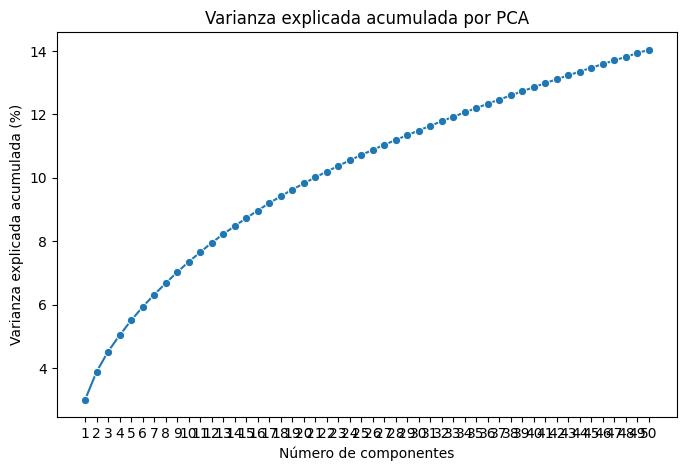

In [ ]:
# TODO: Genere una visualización que muestre cómo varía la varianza explicada
# a medida que se agregan componentes PCA (por ejemplo, hasta 10 componentes).

n_components = 50

pca = PCA(n_components=n_components)

X_pca_10 = pca.fit_transform(X_train_tfidf)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

components = np.arange(1, n_components + 1)

plt.figure(figsize=(8, 5))

sns.lineplot(
    x=components,
    y=cumulative_variance * 100,
    marker="o"
)

plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada (%)")
plt.xticks(components)
plt.show()


# Parte 2: Entrenamiento y Evaluación de Modelos

## 1. Multinomial Naive Bayes
Entrene el modelo *Multinomial Naive Bayes* para clasificar los artículos según a qué medio de prensa pertenece el texto.
Utilice dicho modelo para clasificar los artículos del conjunto de test, y reporte el valor de *accuracy* y la **matriz de confusión**.
Reporte además el valor de *precision* y *recall* para cada medio.
Explique cómo se relacionan estos valores con la matriz anterior.

¿Qué problemas puede tener el hecho de mirar solamente el valor de *accuracy*?
Considere qué sucedería con esta métrica si el desbalance de datos fuera aún mayor entre medios.

**Sugerencia**: utilice el método `from_predictions` de `ConfusionMatrixDisplay` para realizar la matriz.

In [ ]:
# TODO: Entrene Multinomial Naive Bayes sobre X_train_tfidf
model = MultinomialNB()

model.fit(X_train_tfidf, y_train[X_train.notna()])

MultinomialNB()

accuracy: 0.6957803992740472


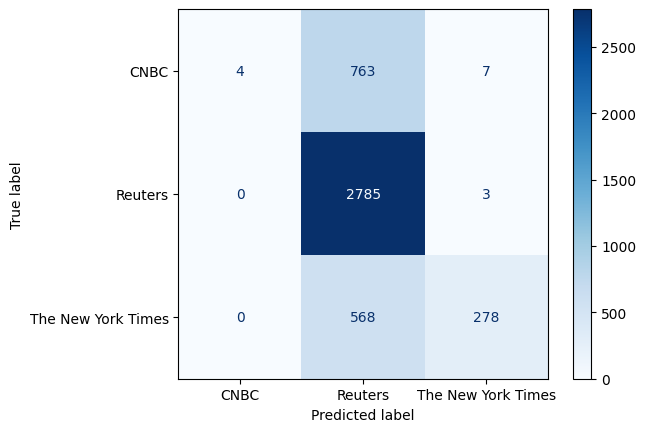

In [ ]:
# TODO: Evalúe el modelo sobre el conjunto de test
X_test_tfidf = tf_idf_vectorizer.transform(X_test[X_test.notna()])

prediction = model.predict(X_test_tfidf)

acc = accuracy_score(y_test[X_test.notna()], prediction)
print(f"accuracy: {acc}")

labels = sorted(y_test[X_test.notna()].unique())

cm = confusion_matrix(y_test[X_test.notna()], prediction, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
print(classification_report(y_test[X_test.notna()], prediction))

                    precision    recall  f1-score   support

              CNBC       1.00      0.01      0.01       774
           Reuters       0.68      1.00      0.81      2788
The New York Times       0.97      0.33      0.49       846

          accuracy                           0.70      4408
         macro avg       0.88      0.44      0.44      4408
      weighted avg       0.79      0.70      0.61      4408



## 2. Validación cruzada y búsqueda de hiperparámetros
Explique cómo funciona la técnica de **validación cruzada** (*cross-validation*).
Implemente una búsqueda de hiperparámetros usando `GridSearchCV`.
Genere una visualización que permita comparar las métricas (por ejemplo, *accuracy*) de los distintos modelos entrenados, viendo el valor promedio y la variabilidad de las mismas en todos los *splits* (por ejemplo, en un gráfico de violín).

In [ ]:
# TODO: Defina la grilla de hiperparámetros y ejecute GridSearchCV
cv_model = MultinomialNB()

param_grid = {
    "alpha": np.arange(0.1, 1.1, 0.1)
}

grid_search = GridSearchCV(estimator=cv_model, param_grid=param_grid, cv=10, scoring="accuracy", n_jobs=-1)

grid_search.fit(X_train_tfidf, y_train[X_train.notna()])

GridSearchCV(cv=10, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])},
             scoring='accuracy')

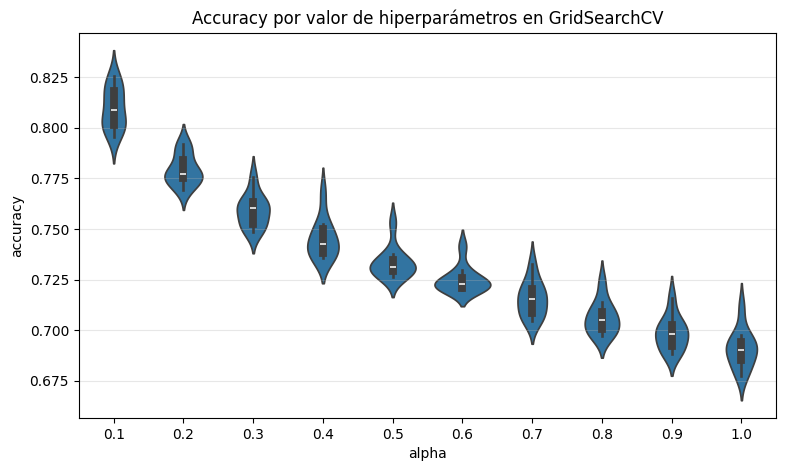

In [ ]:
# TODO: Genere una visualización (por ejemplo, gráfico de violín) que compare
# la accuracy de los distintos modelos entrenados en GridSearchCV,
# mostrando la variabilidad en los distintos splits.
results = pd.DataFrame(grid_search.cv_results_)

split_cols = [col for col in results.columns if col.startswith("split") and col.endswith("_test_score")]

scores = results[["param_alpha"] + split_cols]
scores_long = scores.melt(
    id_vars="param_alpha",
    value_vars=split_cols,
    var_name="split",
    value_name="accuracy"
)
scores_long["alpha"] = scores_long["param_alpha"].astype(float).round(2)

plt.figure(figsize=(9, 5))

sns.violinplot(
    data=scores_long,
    x="alpha",
    y="accuracy"
)

plt.title("Accuracy por valor de hiperparámetros en GridSearchCV")
plt.xlabel("alpha")
plt.ylabel("accuracy")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 3. Entrenamiento final con el mejor modelo
Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación).
Reporte el valor final de las métricas y la matriz de confusión.
Discuta las limitaciones de utilizar un modelo basado en *bag of words* o TF-IDF para el análisis de texto.

In [ ]:
# TODO: Entrene el mejor modelo sobre todo el conjunto de entrenamiento
best_model = grid_search.best_estimator_
best_model.alpha

np.float64(0.1)

accuracy: 0.8130671506352087


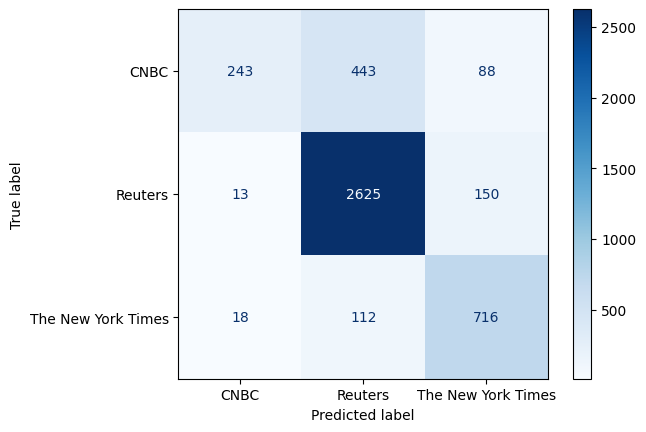

In [ ]:
# TODO: Evalúe el mejor modelo sobre el conjunto de test y reporte métricas finales
prediction_2 = best_model.predict(X_test_tfidf)

acc_2 = accuracy_score(y_test[X_test.notna()], prediction_2)
print(f"accuracy: {acc_2}")

cm_2 = confusion_matrix(y_test[X_test.notna()], prediction_2, labels=labels)

disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=labels)
disp_2.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
print(classification_report(y_test[X_test.notna()], prediction_2))

                    precision    recall  f1-score   support

              CNBC       0.89      0.31      0.46       774
           Reuters       0.83      0.94      0.88      2788
The New York Times       0.75      0.85      0.80       846

          accuracy                           0.81      4408
         macro avg       0.82      0.70      0.71      4408
      weighted avg       0.82      0.81      0.79      4408



## 4. Modelo alternativo
Evalúe al menos un modelo más (dentro de scikit-learn) aparte de *Multinomial Naive Bayes* para clasificar el texto utilizando las mismas *features* de texto.
Explique brevemente cómo funciona y compare los resultados con el anterior.

In [ ]:
# TODO: Entrene al menos un modelo alternativo de scikit-learn
from sklearn.linear_model import LogisticRegressionCV

log_reg_model = LogisticRegressionCV(cv=10, scoring="accuracy", n_jobs=-1)

log_reg_model.fit(X_train_tfidf, y_train[X_train.notna()])

LogisticRegressionCV(cv=10, n_jobs=-1, scoring='accuracy')

accuracy: 0.8995009074410163


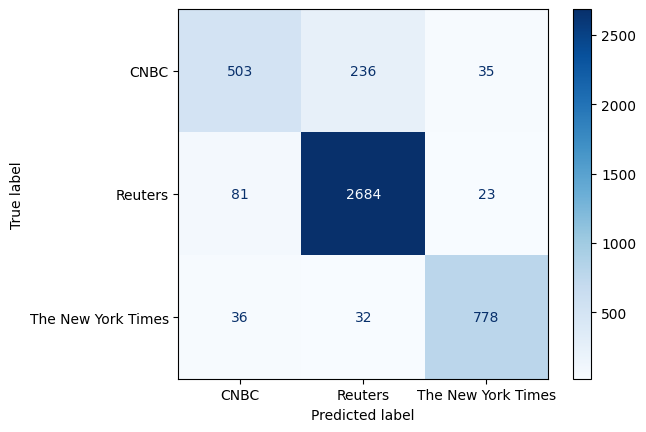

In [ ]:
log_reg_pred = log_reg_model.predict(X_test_tfidf)

log_reg_acc = accuracy_score(y_test[X_test.notna()], log_reg_pred)
print(f"accuracy: {log_reg_acc}")

log_reg_cm = confusion_matrix(y_test[X_test.notna()], log_reg_pred, labels=labels)

log_reg_disp = ConfusionMatrixDisplay(confusion_matrix=log_reg_cm, display_labels=labels)
log_reg_disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
print(classification_report(y_test[X_test.notna()], log_reg_pred))

                    precision    recall  f1-score   support

              CNBC       0.81      0.65      0.72       774
           Reuters       0.91      0.96      0.94      2788
The New York Times       0.93      0.92      0.93       846

          accuracy                           0.90      4408
         macro avg       0.88      0.84      0.86      4408
      weighted avg       0.90      0.90      0.90      4408



## 5. Cambio de medio de prensa
Evalúe el problema cambiando al menos un medio de prensa.
En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.
Puede ser útil comentar acerca de técnicas como sobre-muestreo y submuestreo; no es necesario implementarlas.

In [ ]:
# TODO: Seleccione una combinación diferente de tres medios de prensa (cambiando al menos uno)
# y repita el proceso de entrenamiento y evaluación.
counts = df["publication"].value_counts()
top_2_publications = counts.head(2)
third_publication = counts.iloc[2:].sample(n=1, random_state=33)

publication_new_selection = pd.concat([top_2_publications, third_publication])
changed_df = df[df["publication"].isin(publication_new_selection.index)]


changed_df.head()
# Analice el balance de clases en este nuevo conjunto de datos
# ...

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,None,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,None,Vox
6,7,7,2018-12-04,2018,12.0,4,None,Bank of Montreal's quarterly earnings beat mar...,"TORONTO, Dec 4 (Reuters) - Bank of Montreal on...",https://www.reuters.com/article/bmo-results/ba...,Company News,Reuters
8,9,9,2019-05-23 09:30:04,2019,5.0,23,Michael Kolomatsky,Are Beach House Rentals Profitable?,"Calculator Sure, if you choose the right place...",https://www.nytimes.com/2019/05/23/realestate/...,realestate,The New York Times
9,10,10,2018-12-30 08:33:24,2018,12.0,30,The Associated Press,Colombia Investigates a Possible Plot to Assas...,"BOGOTÁ, Colombia — Colombia is investigating a...",https://www.nytimes.com/2018/12/30/world/ameri...,world,The New York Times


In [ ]:
changed_df["CleanText"] = clean_text(changed_df, "article")

Caracteres no alfabéticos encontrados: 123


/tmp/ipykernel_4007/3950987213.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  changed_df["CleanText"] = clean_text(changed_df, "article")


In [ ]:
X_new = changed_df["CleanText"]
y_new = changed_df["publication"]

X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new[X_new.notna()], y_new[X_new.notna()], random_state=78, stratify=y_new[X_new.notna()])

In [ ]:
tf_idf_vectorizer_new = TfidfVectorizer()

X_train_tfidf_new = tf_idf_vectorizer_new.fit_transform(X_new_train)

X_train_tfidf_new.shape

(9473, 86387)

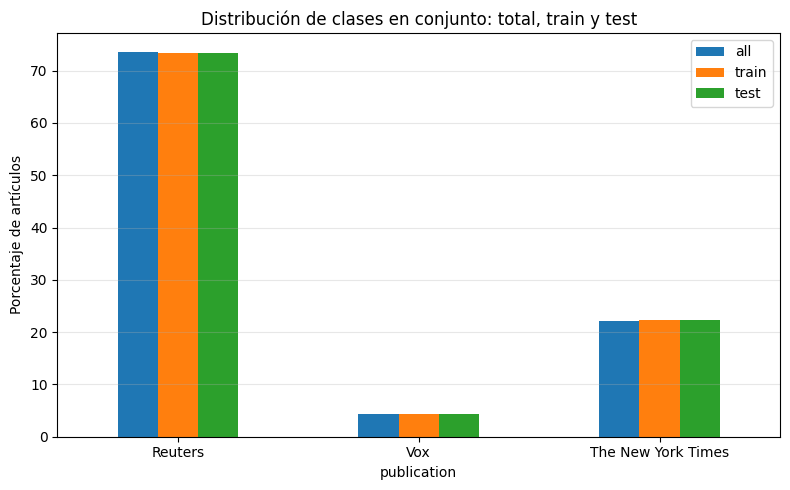

In [ ]:
classes = y_new.unique()

new_distribution = pd.DataFrame({
    "all": y_new.value_counts(normalize=True).reindex(classes) * 100,
    "train": y_new_train.value_counts(normalize=True).reindex(classes) * 100,
    "test": y_new_test.value_counts(normalize=True).reindex(classes) * 100
})

ax_new = new_distribution.plot(kind="bar", figsize=(8, 5))

ax_new.set_title("Distribución de clases en conjunto: total, train y test")
ax_new.set_xlabel("publication")
ax_new.set_ylabel("Porcentaje de artículos")
ax_new.legend()
ax_new.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

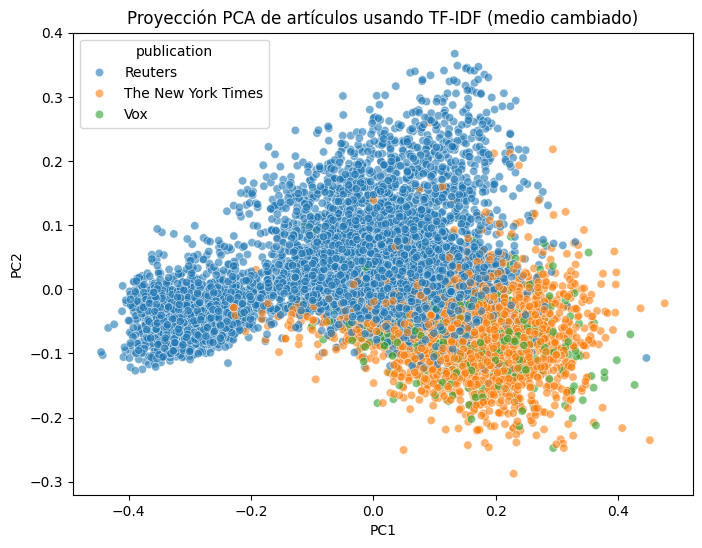

In [ ]:


X_pca_new = PCA(n_components=2).fit_transform(X_train_tfidf_new)

pca_new_df = pd.DataFrame({
    "PC1": X_pca_new[:, 0],
    "PC2": X_pca_new[:, 1],
    "publication": y_new_train
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_new_df,
    x="PC1",
    y="PC2",
    hue="publication",
    alpha=0.6
)

plt.title("Proyección PCA de artículos usando TF-IDF (medio cambiado)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="publication")
plt.show()

In [ ]:
new_model = MultinomialNB()

new_model.fit(X_train_tfidf_new, y_new_train)

MultinomialNB()

accuracy: 0.8106396453451552


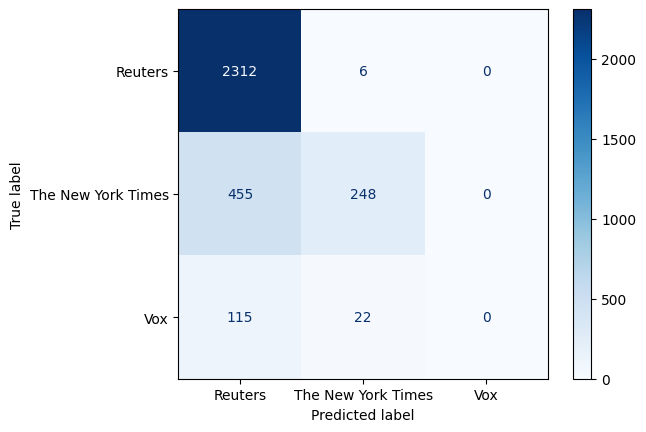

In [ ]:
X_test_tfidf_new = tf_idf_vectorizer_new.transform(X_new_test)
new_labels = sorted(y_new_test.unique())

new_predictions = new_model.predict(X_test_tfidf_new)

new_acc = accuracy_score(y_new_test, new_predictions)
print(f"accuracy: {new_acc}")

new_cm = confusion_matrix(y_new_test, new_predictions, labels=new_labels)

new_disp = ConfusionMatrixDisplay(confusion_matrix=new_cm, display_labels=new_labels)
new_disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
print(classification_report(y_new_test, new_predictions))

                    precision    recall  f1-score   support

           Reuters       0.80      1.00      0.89      2318
The New York Times       0.90      0.35      0.51       703
               Vox       0.00      0.00      0.00       137

          accuracy                           0.81      3158
         macro avg       0.57      0.45      0.47      3158
      weighted avg       0.79      0.81      0.77      3158



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6. Técnica alternativa de extracción de features
Busque información sobre al menos una técnica alternativa de extraer *features* de texto.
Explique brevemente cómo funciona y qué tipo de diferencias esperaría en los resultados.
No se espera que implemente nada en esta parte.

*TODO: Escriba su análisis en el informe.*

## 7. Opcional: Clasificación a nivel de título
Repita la clasificación con los tres medios de prensa originales, pero esta vez clasificando a nivel de **título** en lugar de artículo completo.

Caracteres no alfabéticos encontrados: 58


/tmp/ipykernel_4007/2364551317.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_3["CleanText_T"] = clean_text(df_top_3, "title")


accuracy: 0.7522935779816514


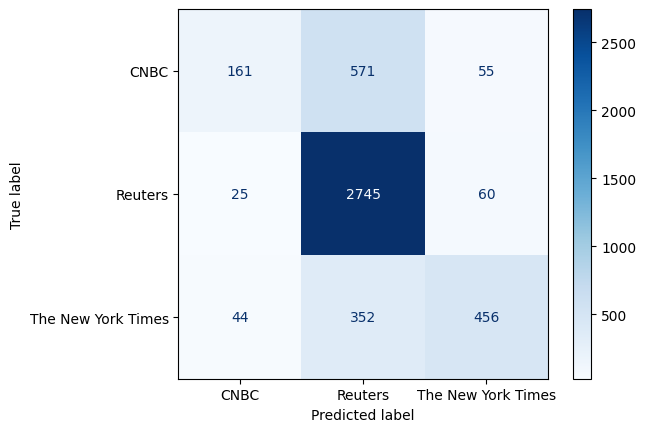

                    precision    recall  f1-score   support

              CNBC       0.70      0.20      0.32       787
           Reuters       0.75      0.97      0.84      2830
The New York Times       0.80      0.54      0.64       852

          accuracy                           0.75      4469
         macro avg       0.75      0.57      0.60      4469
      weighted avg       0.75      0.75      0.71      4469



In [ ]:
df_top_3["CleanText_T"] = clean_text(df_top_3, "title")
X_t = df_top_3["CleanText_T"]
y_t = df_top_3["publication"]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t, y_t, test_size=0.3, random_state=43, stratify=y_t)

cv_model = MultinomialNB()
tf_idf_vectorizer_t = TfidfVectorizer()

X_train_tfidf_t = tf_idf_vectorizer_t.fit_transform(X_train_t[X_train_t.notna()])

param_grid = {
    "alpha": np.arange(0.1, 1.1, 0.1)
}

grid_search = GridSearchCV(estimator=cv_model, param_grid=param_grid, cv=10, scoring="accuracy", n_jobs=-1)

grid_search.fit(X_train_tfidf_t, y_train_t[X_train_t.notna()])
best_model = grid_search.best_estimator_

X_test_tfidf_t = tf_idf_vectorizer_t.transform(X_test_t[X_test_t.notna()])
prediction_2 = best_model.predict(X_test_tfidf_t)

acc_2 = accuracy_score(y_test_t[X_test_t.notna()], prediction_2)
print(f"accuracy: {acc_2}")

cm_2 = confusion_matrix(y_test_t[X_test_t.notna()], prediction_2, labels=labels)

disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=labels)
disp_2.plot(cmap=plt.cm.Blues)
plt.show()
print(classification_report(y_test_t[X_test_t.notna()], prediction_2))